# HR Employee Attrition Prediction — Completed EDA & Preprocessing

**Dataset:** IBM HR Analytics Employee Attrition & Performance  
**Source:** Kaggle — `pavansubhasht/ibm-hr-analytics-attrition-dataset`

In [1]:
!pip -q install kagglehub


In [2]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Colab/Kaggle path when available; local fallback for reproducibility outside Kaggle.
candidate_paths = [
    "/mnt/data/WA_Fn-UseC_-HR-Employee-Attrition.csv",
    "/mnt/data/hrfinal/WA_Fn-UseC_-HR-Employee-Attrition.csv",
    "/mnt/data/project/WA_Fn-UseC_-HR-Employee-Attrition.csv",
]
local_csv = next((p for p in candidate_paths if os.path.exists(p)), None)
if local_csv is not None:
    dataset_path = os.path.dirname(local_csv)
else:
    try:
        import kagglehub
        dataset_path = kagglehub.dataset_download("pavansubhasht/ibm-hr-analytics-attrition-dataset")
    except Exception as e:
        raise FileNotFoundError("Dataset not found locally and Kaggle download failed. Upload WA_Fn-UseC_-HR-Employee-Attrition.csv.") from e

print("Dataset directory:", dataset_path)

100%|██████████| 50.1k/50.1k [00:00<00:00, 41.7MB/s]

Extracting files...
Dataset directory: /root/.cache/kagglehub/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset/versions/1


In [3]:
csv_files = glob.glob(os.path.join(dataset_path, "*.csv"))
if not csv_files:
    raise FileNotFoundError("No CSV file was found. Upload WA_Fn-UseC_-HR-Employee-Attrition.csv or run in an environment with Kaggle access.")

csv_path = csv_files[0]
df = pd.read_csv(csv_path)

print("CSV used:", csv_path)
print("Shape:", df.shape)
display(df.head())

CSV used: /root/.cache/kagglehub/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset/versions/1/WA_Fn-UseC_-HR-Employee-Attrition.csv
Shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


## 1. Initial EDA — Dataset Structure

In [4]:
# Basic structure
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

Number of rows: 1470
Number of columns: 35

Column names:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Data types:


,dtype
Age,int64
Attrition,object
BusinessTravel,object
DailyRate,int64
Department,object
DistanceFromHome,int64
Education,int64
EducationField,object
EmployeeCount,int64
EmployeeNumber,int64


In [5]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [6]:
# Statistical summary
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,1470.0,NaN,NaN,NaN,36.92381,9.135373,18.0,30.0,36.0,43.0,60.0
Attrition,1470,2,No,1233,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BusinessTravel,1470,3,Travel_Rarely,1043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DailyRate,1470.0,NaN,NaN,NaN,802.485714,403.5091,102.0,465.0,802.0,1157.0,1499.0
Department,1470,3,Research & Development,961,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DistanceFromHome,1470.0,NaN,NaN,NaN,9.192517,8.106864,1.0,2.0,7.0,14.0,29.0
Education,1470.0,NaN,NaN,NaN,2.912925,1.024165,1.0,2.0,3.0,4.0,5.0
EducationField,1470,6,Life Sciences,606,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeCount,1470.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
EmployeeNumber,1470.0,NaN,NaN,NaN,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0


In [7]:
# Duplicate records
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [8]:
# Missing values
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

missing_table = pd.DataFrame({
    "Missing Count": missing,
    "Missing Percentage": missing_pct
})

display(missing_table[missing_table["Missing Count"] > 0])

if missing.sum() == 0:
    print("No missing values were found in the dataset.")

,Missing Count,Missing Percentage


No missing values were found in the dataset.


## 2. Target Variable Analysis

,count
Attrition,
No,1233
Yes,237


,Percentage
Attrition,
No,83.88
Yes,16.12


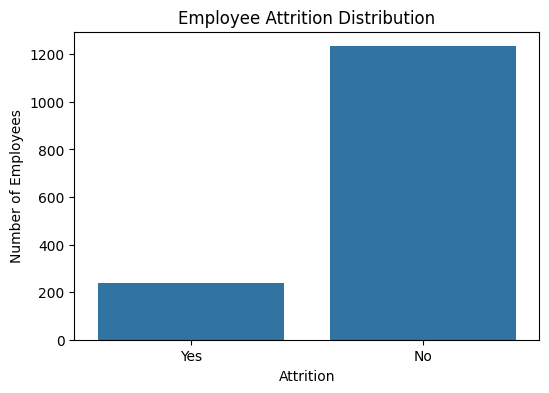

In [9]:
# Target distribution
display(df["Attrition"].value_counts())
display(df["Attrition"].value_counts(normalize=True).mul(100).round(2).rename("Percentage"))

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Attrition", color="C0")
plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")
plt.show()

In [10]:
# Numeric encoding only for quick analysis
target_map = {"No": 0, "Yes": 1}
df["Attrition_Binary"] = df["Attrition"].map(target_map)

print("Attrition rate:", round(df["Attrition_Binary"].mean() * 100, 2), "%")

Attrition rate: 16.12 %


## 3. Categorical and Numerical Features

In [11]:
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

print("Categorical columns:")
print(categorical_cols)

print("\nNumerical columns:")
print(numeric_cols)

Categorical columns:
['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']

Numerical columns:
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'Attrition_Binary']


In [12]:
# Cardinality of categorical variables
cat_cardinality = pd.DataFrame({
    "Unique Values": df[categorical_cols].nunique(),
    "Missing Values": df[categorical_cols].isnull().sum()
}).sort_values("Unique Values", ascending=False)

display(cat_cardinality)

,Unique Values,Missing Values
JobRole,9,0
EducationField,6,0
MaritalStatus,3,0
Department,3,0
BusinessTravel,3,0
Attrition,2,0
Gender,2,0
OverTime,2,0
Over18,1,0


## 4. Initial EDA — Important HR Relationships

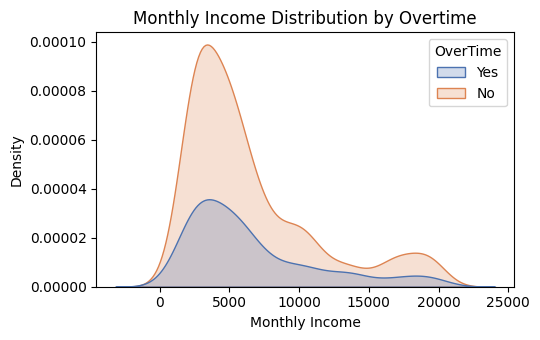

In [13]:
# Attrition by overtime
plt.figure(figsize=(5.5, 3.5))

sns.kdeplot(
    data=df,
    x="MonthlyIncome",
    hue="OverTime",
    fill=True,
    palette="deep"
)

plt.title("Monthly Income Distribution by Overtime")
plt.xlabel("Monthly Income")
plt.ylabel("Density")

plt.tight_layout()
plt.show()

,Level,Employees,AttritionRate
0,Level 1 (Very Low),289,22.8%
1,Level 2 (Low),280,16.4%
2,Level 3 (High),442,16.5%
3,Level 4 (Very High),459,11.3%


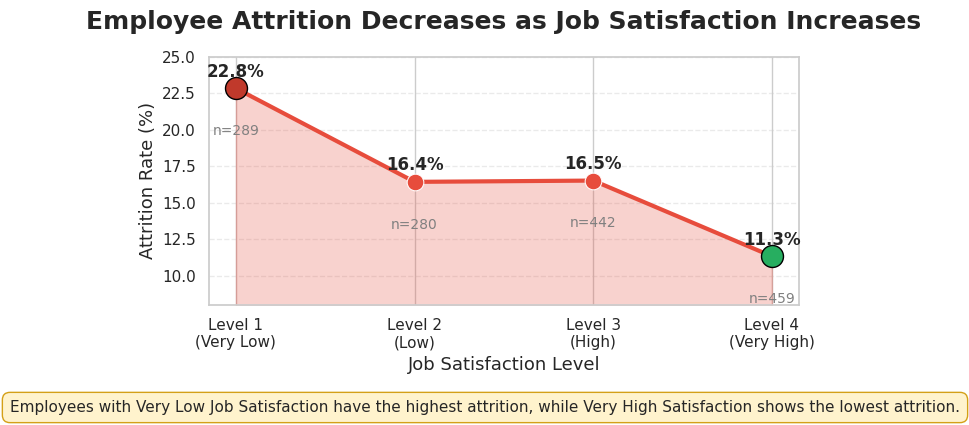

In [14]:
# Job Satisfaction vs Employee Attrition

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Calculate attrition percentage and employee count
summary = (
    df.groupby("JobSatisfaction")["Attrition"]
      .agg(
          AttritionRate=lambda x: (x == "Yes").mean() * 100,
          Employees="count"
      )
      .reset_index()
)

# Friendly labels
summary["Level"] = [
    "Level 1\n(Very Low)",
    "Level 2\n(Low)",
    "Level 3\n(High)",
    "Level 4\n(Very High)"
]

# Display summary table
display(summary[["Level", "Employees", "AttritionRate"]].style.format({
    "AttritionRate": "{:.1f}%"
}))

# Create figure
plt.figure(figsize=(7,4))

# Line plot
sns.lineplot(
    data=summary,
    x="Level",
    y="AttritionRate",
    marker="o",
    linewidth=3,
    markersize=12,
    color="#E74C3C"
)

# Fill area under the curve
plt.fill_between(
    range(len(summary)),
    summary["AttritionRate"],
    alpha=0.25,
    color="#E74C3C"
)

# Annotate each point
for i, row in summary.iterrows():
    plt.text(
        i,
        row["AttritionRate"] + 0.8,
        f"{row['AttritionRate']:.1f}%",
        ha="center",
        fontsize=12,
        fontweight="bold"
    )

    plt.text(
        i,
        row["AttritionRate"] - 3.2,
        f"n={row['Employees']}",
        ha="center",
        fontsize=10,
        color="gray"
    )

# Highlight highest and lowest
plt.scatter(
    summary["Level"].iloc[0],
    summary["AttritionRate"].iloc[0],
    s=250,
    color="#C0392B",
    edgecolor="black",
    zorder=5
)

plt.scatter(
    summary["Level"].iloc[-1],
    summary["AttritionRate"].iloc[-1],
    s=250,
    color="#27AE60",
    edgecolor="black",
    zorder=5
)

# Formatting
plt.title(
    "Employee Attrition Decreases as Job Satisfaction Increases",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.xlabel("Job Satisfaction Level", fontsize=13)
plt.ylabel("Attrition Rate (%)", fontsize=13)

plt.ylim(8,25)

plt.grid(axis="y", linestyle="--", alpha=0.4)

# Insight box
plt.figtext(
    0.5,
    -0.05,
    "Employees with Very Low Job Satisfaction have the highest attrition, while Very High Satisfaction shows the lowest attrition.",
    ha="center",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.5",
              facecolor="#FFF3CD",
              edgecolor="#D4A017")
)

plt.tight_layout()
plt.show()

,Attrition Rate (%)
BusinessTravel,
Non-Travel,8.00
Travel_Rarely,14.96
Travel_Frequently,24.91


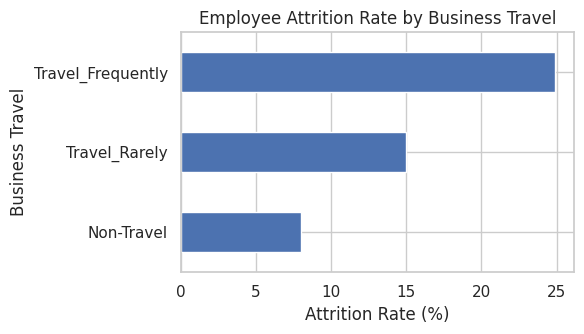

In [15]:
# Attrition by business travel — horizontal attrition-rate bar chart
travel_rate = (
    df.groupby("BusinessTravel")["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values(ascending=True)
)

display(travel_rate.to_frame("Attrition Rate (%)").round(2))

plt.figure(figsize=(6, 3.5))
travel_rate.plot(kind="barh")
plt.title("Employee Attrition Rate by Business Travel")
plt.xlabel("Attrition Rate (%)")
plt.ylabel("Business Travel")
plt.tight_layout()
plt.show()

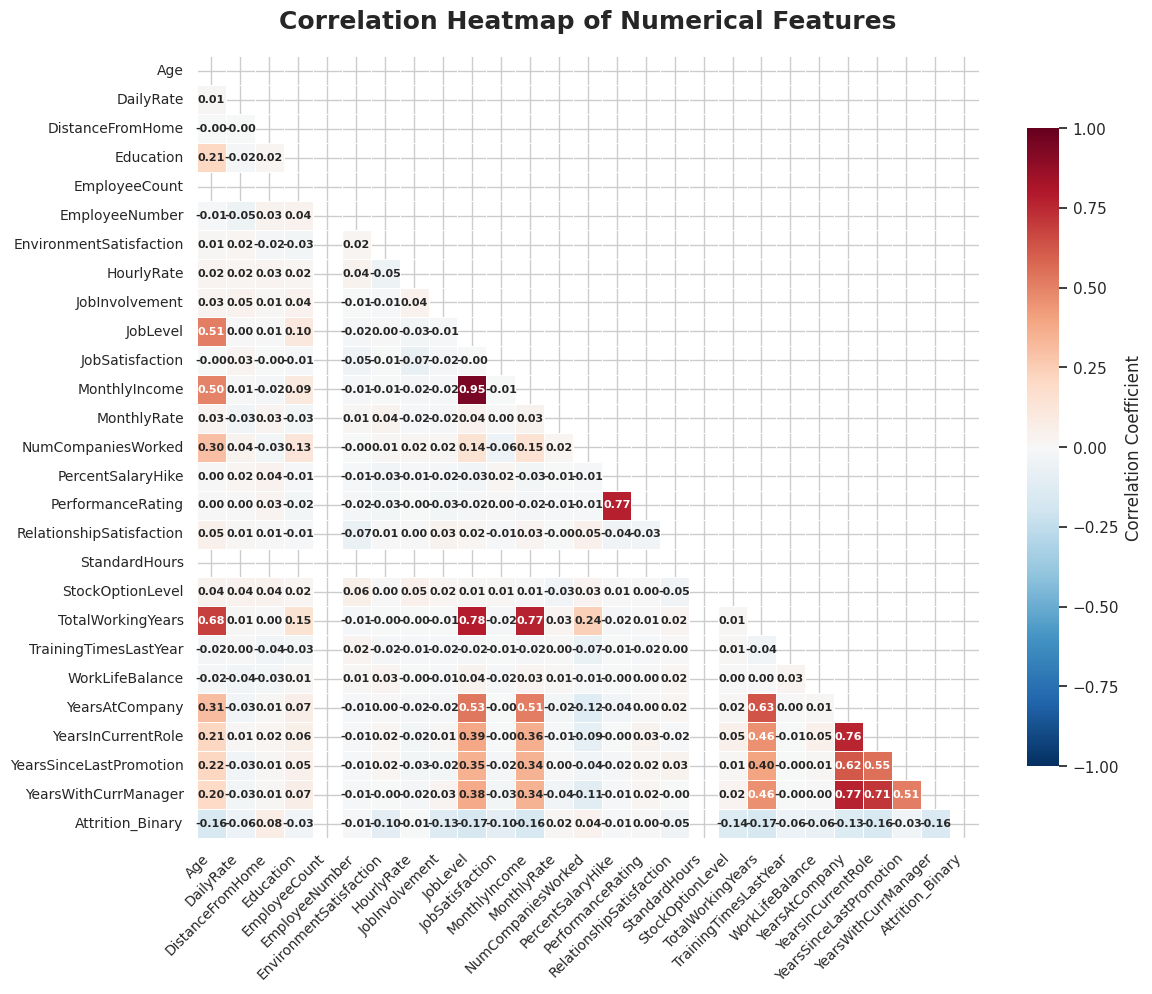

In [16]:
# Correlation Heatmap

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical features only
numeric_for_corr = df.select_dtypes(include=np.number)

# Compute correlation matrix
corr_matrix = numeric_for_corr.corr()

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot
plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={
        "label": "Correlation Coefficient",
        "shrink": 0.8
    },
    annot_kws={
        "size": 8,
        "weight": "bold"
    }
)

plt.title(
    "Correlation Heatmap of Numerical Features",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

## 4A. Additional Distribution and Relationship Plots

Different plot types are used for different analytical questions instead of repeatedly using countplots.


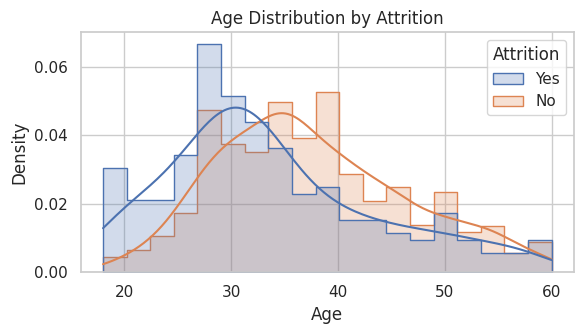

In [17]:
# Numerical distribution — histogram with KDE
plt.figure(figsize=(6, 3.5))
sns.histplot(
    data=df,
    x="Age",
    hue="Attrition",
    kde=True,
    element="step",
    stat="density",
    common_norm=False,
    palette="deep"
)
plt.title("Age Distribution by Attrition")
plt.xlabel("Age")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

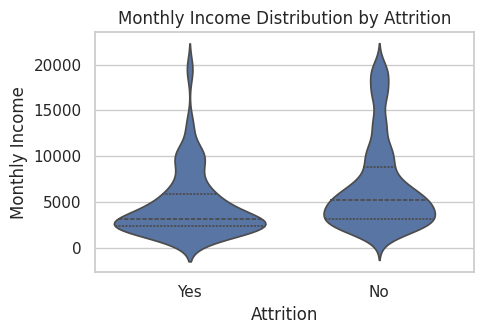

In [18]:
# Monthly income — violin plot
plt.figure(figsize=(5, 3.5))
sns.violinplot(
    data=df,
    x="Attrition",
    y="MonthlyIncome",
    inner="quartile",
    color="C0"
)
plt.title("Monthly Income Distribution by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")
plt.tight_layout()
plt.show()

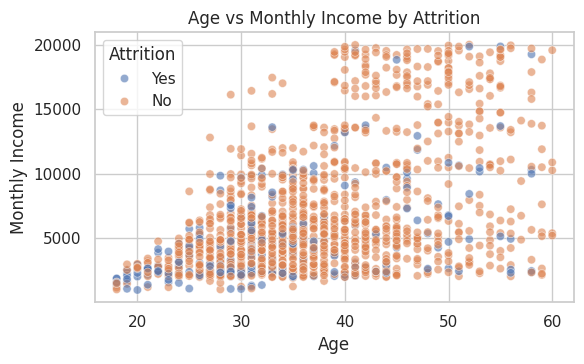

In [19]:
# Numerical relationship — scatter plot
plt.figure(figsize=(6, 3.8))
sns.scatterplot(
    data=df,
    x="Age",
    y="MonthlyIncome",
    hue="Attrition",
    alpha=0.6,
    palette="deep"
)
plt.title("Age vs Monthly Income by Attrition")
plt.xlabel("Age")
plt.ylabel("Monthly Income")
plt.tight_layout()
plt.show()


## 5. Finalized Preprocessing

The finalized workflow keeps the untouched test set separate and uses leakage-safe preprocessing. Constant and identifier-like columns are removed automatically. Categorical variables are one-hot encoded. Numerical variables are scaled for distance/linear models. Tree-based models use the same one-hot representation but **do not use PCA**, because PCA can discard useful feature-level splits for tree learners.

In [20]:
# Finalized data cleaning and target encoding
data = df.copy()
data = data.drop(columns=["Attrition_Binary"], errors="ignore")

constant_columns = [
    col for col in data.columns
    if col != "Attrition" and data[col].nunique(dropna=False) <= 1
]
id_like_columns = [
    col for col in data.columns
    if col != "Attrition"
    and data[col].nunique(dropna=False) == len(data)
]
auto_drop_columns = sorted(set(constant_columns + id_like_columns))
data = data.drop(columns=auto_drop_columns, errors="ignore")
data["Attrition"] = data["Attrition"].map({"No": 0, "Yes": 1})

print("Dropped constant/ID-like columns:", auto_drop_columns)
print("Final raw modeling shape:", data.shape)

Dropped constant/ID-like columns: ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
Final raw modeling shape: (1470, 31)


In [21]:
# Domain-driven feature engineering
def add_hr_features(X):
    X = X.copy()

    # Career progression and tenure ratios
    X["YearsSincePromotionRatio"] = X["YearsSinceLastPromotion"] / (X["YearsAtCompany"] + 1)
    X["CurrentRoleRatio"] = X["YearsInCurrentRole"] / (X["YearsAtCompany"] + 1)
    X["ManagerTenureRatio"] = X["YearsWithCurrManager"] / (X["YearsAtCompany"] + 1)
    X["CompanyExperienceRatio"] = X["YearsAtCompany"] / (X["TotalWorkingYears"] + 1)

    # Compensation/experience relationships
    X["IncomePerJobLevel"] = X["MonthlyIncome"] / (X["JobLevel"] + 1)
    X["IncomePerYearExperience"] = X["MonthlyIncome"] / (X["TotalWorkingYears"] + 1)
    X["YearsAtCompanyRatioToAge"] = X["YearsAtCompany"] / (X["Age"] + 1)
    X["JobLevelPerYear"] = X["JobLevel"] / (X["TotalWorkingYears"] + 1)

    # Satisfaction and workload summaries
    satisfaction_cols = [
        "EnvironmentSatisfaction", "JobInvolvement", "JobSatisfaction",
        "RelationshipSatisfaction", "WorkLifeBalance"
    ]
    X["SatisfactionAvg"] = X[satisfaction_cols].mean(axis=1)
    X["WorkPressureScore"] = (
        X["OverTime"].map({"Yes": 1, "No": 0})
        + (4 - X["WorkLifeBalance"]) / 4
        + (4 - X["JobSatisfaction"]) / 4
    )

    # Simple career-stage indicators
    X["EarlyCareer"] = ((X["Age"] < 30) & (X["TotalWorkingYears"] < 5)).astype(int)
    X["FrequentJobChanges"] = (
        (X["NumCompaniesWorked"] >= 3) &
        (X["TotalWorkingYears"] <= 10)
    ).astype(int)

    # Interactions that are meaningful for attrition
    X["OverTime_JobSatisfaction"] = (
        X["OverTime"].astype(str) + "_" + X["JobSatisfaction"].astype(str)
    )
    X["OverTime_WorkLifeBalance"] = (
        X["OverTime"].astype(str) + "_" + X["WorkLifeBalance"].astype(str)
    )
    X["OverTime_JobLevel"] = (
        X["OverTime"].astype(str) + "_" + X["JobLevel"].astype(str)
    )
    X["Marital_OverTime"] = (
        X["MaritalStatus"].astype(str) + "_" + X["OverTime"].astype(str)
    )
    X["JobRole_OverTime"] = (
        X["JobRole"].astype(str) + "_" + X["OverTime"].astype(str)
    )

    return X

X = add_hr_features(data.drop(columns=["Attrition"]))
y = data["Attrition"]

print("Features after domain-driven engineering:", X.shape[1])

Features after domain-driven engineering: 47


In [22]:
# Leakage-safe 70/15/15 stratified split
from sklearn.model_selection import train_test_split

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=(0.15 / 0.85), random_state=42, stratify=y_train_val
)

print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Testing:", X_test.shape, y_test.shape)
print("\nClass distribution:")
display(pd.DataFrame({
    "Train %": y_train.value_counts(normalize=True).mul(100),
    "Validation %": y_val.value_counts(normalize=True).mul(100),
    "Test %": y_test.value_counts(normalize=True).mul(100)
}).rename(index={0:"Stayed (0)",1:"Left (1)"}).round(2))

Training: (1028, 47) (1028,)
Validation: (221, 47) (221,)
Testing: (221, 47) (221,)

Class distribution:


,Train %,Validation %,Test %
Attrition,,,
Stayed (0),83.95,83.71,83.71
Left (1),16.05,16.29,16.29


### Two finalized preprocessing pipelines

*   List item
*   List item



**Linear/distance models:** One-Hot Encoding → StandardScaler.  
**Tree/boosting models:** One-Hot Encoding → no scaling → no PCA.

This separation is intentional: scaling/PCA are useful for Logistic Regression, SVM and KNN, while tree models can work directly on the encoded features.

In [23]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()
numeric_features = X_train.select_dtypes(exclude=["object"]).columns.tolist()

linear_preprocessor = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                      ("scaler", StandardScaler())]), numeric_features),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical_features)
])

tree_preprocessor = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), numeric_features),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical_features)
])

print("Categorical features:", len(categorical_features))
print("Numerical features:", len(numeric_features))

Categorical features: 12
Numerical features: 35


## 6. Finalized EDA

The earlier EDA is retained and extended with a compact, reproducible summary of data quality, class imbalance, numeric distributions, categorical cardinality and the strongest numeric correlations with the binary attrition target.

In [24]:
# Finalized EDA summary
eda_summary = pd.DataFrame({
    "dtype": data.drop(columns="Attrition").dtypes,
    "missing": data.drop(columns="Attrition").isna().sum(),
    "unique": data.drop(columns="Attrition").nunique()
}).sort_values(["dtype", "unique"])

print("Rows:", len(data))
print("Columns:", data.shape[1])
print("Duplicates:", data.duplicated().sum())
print("Attrition rate:", y.mean().round(4))
display(eda_summary.head(40))

# Numeric relationships with attrition
numeric_eda = data.drop(columns="Attrition").select_dtypes(include=np.number).copy()
numeric_eda["Attrition_Binary"] = y
corr_with_target = (
    numeric_eda.corr(numeric_only=True)["Attrition_Binary"]
    .drop("Attrition_Binary")
    .sort_values(key=np.abs, ascending=False)
)
display(corr_with_target.head(15).to_frame("Correlation with Attrition"))

Rows: 1470
Columns: 31
Duplicates: 0
Attrition rate: 0.1612


,dtype,missing,unique
PerformanceRating,int64,0,2
EnvironmentSatisfaction,int64,0,4
JobInvolvement,int64,0,4
JobSatisfaction,int64,0,4
RelationshipSatisfaction,int64,0,4
StockOptionLevel,int64,0,4
WorkLifeBalance,int64,0,4
Education,int64,0,5
JobLevel,int64,0,5
TrainingTimesLastYear,int64,0,7


,Correlation with Attrition
TotalWorkingYears,-0.171063
JobLevel,-0.169105
YearsInCurrentRole,-0.160545
MonthlyIncome,-0.159840
Age,-0.159205
YearsWithCurrManager,-0.156199
StockOptionLevel,-0.137145
YearsAtCompany,-0.134392
JobInvolvement,-0.130016
JobSatisfaction,-0.103481


## 7. Model Implementation


## 8. FINAL — 11-Model Imbalance-Aware Competition

This is the final modeling workflow. **All 11 models from the original project are genuinely trained and compared.** The imbalance methods are not applied only to Logistic Regression.

**Positive class:** `Attrition = Yes = 1` (Left).

We do **not** force the data to 50/50. Instead, each model receives an appropriate imbalance treatment, including different degrees of minority emphasis, and cross-validation decides what works best. Resampling occurs only inside training folds. Validation and test data keep the natural class distribution.

In [25]:
# Final modeling imports
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score, roc_auc_score, average_precision_score,
    confusion_matrix, classification_report, roc_curve, precision_recall_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, SMOTENC, BorderlineSMOTE, ADASYN, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler, NearMiss
from imblearn.combine import SMOTETomek, SMOTEENN

RANDOM_STATE = 42

print("Positive class: 1 = Left/Yes")
display(pd.DataFrame({
    "Train": y_train.value_counts().sort_index(),
    "Validation": y_val.value_counts().sort_index(),
    "Test": y_test.value_counts().sort_index()
}).rename(index={0:"Stayed/No", 1:"Left/Yes"}))

Positive class: 1 = Left/Yes


,Train,Validation,Test
Attrition,,,
Stayed/No,863,185,185
Left/Yes,165,36,36


In [26]:
# Final leakage-safe preprocessors.
# Dense one-hot output also keeps HistGradientBoosting compatible.
linear_preprocessor_final = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_features),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]), categorical_features)
])

tree_preprocessor_final = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median"))
    ]), numeric_features),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]), categorical_features)
])

cat_indices = [X_train.columns.get_loc(c) for c in categorical_features]
print("Categorical columns for SMOTENC:", len(cat_indices))

Categorical columns for SMOTENC: 12


In [27]:
# Metrics: every metric is defined with Left/Yes = positive class.
def score_probabilities(y_true, prob, threshold=0.50):
    y_true = np.asarray(y_true)
    prob = np.asarray(prob)
    pred = (prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, pred, labels=[0,1])
    return {
        "Accuracy": accuracy_score(y_true, pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, pred),
        "Precision": precision_score(y_true, pred, zero_division=0),
        "Recall": recall_score(y_true, pred, zero_division=0),
        "F1": f1_score(y_true, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, prob),
        "PR-AUC": average_precision_score(y_true, prob),
        "Predicted Yes %": pred.mean(),
        "Actual Yes %": y_true.mean(),
        "TN": cm[0,0], "FP": cm[0,1], "FN": cm[1,0], "TP": cm[1,1]
    }

def choose_threshold(y_true, prob):
    rows=[]
    for t in np.round(np.arange(0.10,0.901,0.01),2):
        rows.append({"Threshold":t, **score_probabilities(y_true,prob,t)})
    d=pd.DataFrame(rows)
    d=d.sort_values(
        ["F1","Balanced Accuracy","PR-AUC","Recall","Precision"],
        ascending=False
    )
    return float(d.iloc[0]["Threshold"]), d

print("Selection order: Left F1 -> Balanced Accuracy -> PR-AUC -> Left Recall -> Precision")

Selection order: Left F1 -> Balanced Accuracy -> PR-AUC -> Left Recall -> Precision


### 8.1 Candidate construction

The experiment deliberately tests **partial balancing as well as stronger balancing**. A SMOTE ratio of `0.60` means the minority class becomes 60% of the majority class inside that training fold; it does **not** mean 50/50.

For models with native imbalance controls, class weights or `scale_pos_weight` are tested. For models without native controls, leakage-safe resampling is tested. SMOTENC is applied to the raw mixed-type training data before encoding.

In [28]:
def base_classifier(model_name, variant="baseline"):
    if model_name == "Logistic Regression":
        cw = None if variant=="baseline" else ({0:1,1:float(variant.split("=")[1])} if variant.startswith("weight=") else "balanced")
        clf = LogisticRegression(C=0.5,max_iter=5000,class_weight=cw,random_state=RANDOM_STATE)
        return Pipeline([("preprocessor",linear_preprocessor_final),("classifier",clf)])

    if model_name == "Decision Tree":
        cw = None if variant=="baseline" else "balanced"
        clf = DecisionTreeClassifier(max_depth=6,min_samples_split=10,min_samples_leaf=4,class_weight=cw,random_state=RANDOM_STATE)
        return Pipeline([("preprocessor",tree_preprocessor_final),("classifier",clf)])

    if model_name == "Random Forest":
        cw = None if variant=="baseline" else variant
        clf = RandomForestClassifier(
            n_estimators=250,max_depth=10,min_samples_split=5,min_samples_leaf=2,
            max_features="sqrt",class_weight=cw,random_state=RANDOM_STATE,n_jobs=-1
        )
        return Pipeline([("preprocessor",tree_preprocessor_final),("classifier",clf)])

    if model_name == "Extra Trees":
        cw = None if variant=="baseline" else "balanced"
        clf = ExtraTreesClassifier(
            n_estimators=250,max_depth=12,min_samples_leaf=2,max_features="sqrt",
            class_weight=cw,random_state=RANDOM_STATE,n_jobs=-1
        )
        return Pipeline([("preprocessor",tree_preprocessor_final),("classifier",clf)])

    if model_name == "Gradient Boosting":
        clf = GradientBoostingClassifier(
            n_estimators=250,learning_rate=0.03,max_depth=2,
            min_samples_split=10,min_samples_leaf=4,random_state=RANDOM_STATE
        )
        return Pipeline([("preprocessor",tree_preprocessor_final),("classifier",clf)])

    if model_name == "HistGradientBoosting":
        clf = HistGradientBoostingClassifier(
            learning_rate=0.05,max_depth=6,max_iter=250,l2_regularization=1.0,
            random_state=RANDOM_STATE
        )
        return Pipeline([("preprocessor",tree_preprocessor_final),("classifier",clf)])

    if model_name == "XGBoost":
        spw = 1.0 if variant=="baseline" else float(variant.split("=")[1])
        clf = XGBClassifier(
            n_estimators=250,max_depth=3,learning_rate=0.03,min_child_weight=2,
            subsample=0.9,colsample_bytree=0.9,reg_lambda=2,
            scale_pos_weight=spw,objective="binary:logistic",eval_metric="logloss",
            random_state=RANDOM_STATE,n_jobs=-1,tree_method="hist"
        )
        return Pipeline([("preprocessor",tree_preprocessor_final),("classifier",clf)])

    if model_name == "SVM":
        cw = None if variant=="baseline" else "balanced"
        clf = SVC(kernel="rbf",C=1.0,gamma="scale",probability=True,class_weight=cw,random_state=RANDOM_STATE)
        return Pipeline([("preprocessor",linear_preprocessor_final),("classifier",clf)])

    if model_name == "KNN":
        clf = KNeighborsClassifier(n_neighbors=15,weights="distance",p=2)
        return Pipeline([("preprocessor",linear_preprocessor_final),("classifier",clf)])

    raise ValueError(model_name)

def resampled_pipeline(model_name, kind, ratio):
    pre = linear_preprocessor_final if model_name in ["Logistic Regression","SVM","KNN"] else tree_preprocessor_final
    clf = base_classifier(model_name).named_steps["classifier"]

    if kind=="SMOTE":
        sampler=SMOTE(sampling_strategy=ratio,random_state=RANDOM_STATE,k_neighbors=5)
    elif kind=="SMOTENC":
        sampler=SMOTENC(categorical_features=cat_indices,sampling_strategy=ratio,random_state=RANDOM_STATE,k_neighbors=5)
        return ImbPipeline([("sampler",sampler),("preprocessor",pre),("classifier",clf)])
    elif kind=="BorderlineSMOTE":
        sampler=BorderlineSMOTE(sampling_strategy=ratio,random_state=RANDOM_STATE,k_neighbors=5)
    elif kind=="ADASYN":
        sampler=ADASYN(sampling_strategy=ratio,random_state=RANDOM_STATE,n_neighbors=5)
    elif kind=="RandomOverSampler":
        sampler=RandomOverSampler(sampling_strategy=ratio,random_state=RANDOM_STATE)
    elif kind=="RandomUnderSampler":
        sampler=RandomUnderSampler(sampling_strategy=ratio,random_state=RANDOM_STATE)
    elif kind=="SMOTETomek":
        sampler=SMOTETomek(sampling_strategy=ratio,random_state=RANDOM_STATE)
    elif kind=="SMOTEENN":
        sampler=SMOTEENN(sampling_strategy=ratio,random_state=RANDOM_STATE)
    else:
        raise ValueError(kind)

    return ImbPipeline([("preprocessor",pre),("sampler",sampler),("classifier",clf)])

base_models = [
    "Logistic Regression","Decision Tree","Random Forest","Extra Trees",
    "Gradient Boosting","HistGradientBoosting","XGBoost","SVM","KNN"
]

configs=[]
for m in base_models:
    configs.append((m,"Baseline",base_classifier(m)))

# Native imbalance controls.
for w in [1.5,2.0,2.5,3.0]:
    configs.append(("Logistic Regression",f"ClassWeight {w:g}",base_classifier("Logistic Regression",f"weight={w}")))
configs += [
    ("Decision Tree","ClassWeight balanced",base_classifier("Decision Tree","balanced")),
    ("Random Forest","ClassWeight balanced",base_classifier("Random Forest","balanced")),
    ("Random Forest","ClassWeight balanced_subsample",base_classifier("Random Forest","balanced_subsample")),
    ("Extra Trees","ClassWeight balanced",base_classifier("Extra Trees","balanced")),
    ("SVM","ClassWeight balanced",base_classifier("SVM","balanced")),
]
for spw in [1.5,2.0,2.5,3.0]:
    configs.append(("XGBoost",f"scale_pos_weight {spw:g}",base_classifier("XGBoost",f"spw={spw}")))

# Controlled resampling. Every base family gets imbalance-aware candidates.
for m in base_models:
    for kind in (["SMOTE","SMOTENC"] if m not in ["Gradient Boosting","HistGradientBoosting","KNN"] else ["SMOTE"]):
        configs.append((m,f"{kind} 0.60",resampled_pipeline(m,kind,0.60)))
    if m in ["Gradient Boosting","HistGradientBoosting","KNN"]:
        configs.append((m,"SMOTE 0.80",resampled_pipeline(m,"SMOTE",0.80)))

# Additional strategies for Logistic Regression so it is not assumed that one resampler is best.
for kind in ["BorderlineSMOTE","ADASYN","SMOTETomek","SMOTEENN","RandomOverSampler"]:
    configs.append(("Logistic Regression",f"{kind} 0.60",resampled_pipeline("Logistic Regression",kind,0.60)))

print("Candidates:",len(configs))
print("Base model families:",base_models)

Candidates: 45
Base model families: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Extra Trees', 'Gradient Boosting', 'HistGradientBoosting', 'XGBoost', 'SVM', 'KNN']


### 8.2 Repeated stratified out-of-fold evaluation

All preprocessing and resampling are inside each candidate pipeline and are fitted only on the training portion of each fold. This is the key leakage-control step.

In [29]:
SCREEN_CV=StratifiedKFold(n_splits=5,shuffle=True,random_state=RANDOM_STATE)

def oof_predictions(pipeline,X_data,y_data,cv=SCREEN_CV):
    X_data=X_data.reset_index(drop=True)
    y_arr=np.asarray(y_data)
    prob_sum=np.zeros(len(y_arr))
    prob_count=np.zeros(len(y_arr))
    fold_rows=[]
    for fold,(tr,va) in enumerate(cv.split(X_data,y_arr),1):
        model=clone(pipeline)
        model.fit(X_data.iloc[tr],y_arr[tr])
        prob=model.predict_proba(X_data.iloc[va])[:,1]
        prob_sum[va]+=prob
        prob_count[va]+=1
        fold_rows.append(score_probabilities(y_arr[va],prob,0.50))
    oof=prob_sum/np.maximum(prob_count,1)
    return oof,pd.DataFrame(fold_rows)

results=[]
oof_store={}
for i,(model_name,strategy,pipeline) in enumerate(configs,1):
    try:
        oof,fold_df=oof_predictions(pipeline,X_train,y_train)
        threshold,_=choose_threshold(y_train.values,oof)
        metrics=score_probabilities(y_train.values,oof,threshold)
        results.append({"Model":model_name,"Strategy":strategy,"Threshold":threshold,**metrics,
                        "CV F1 SD":fold_df["F1"].std(),"CV Balanced Accuracy SD":fold_df["Balanced Accuracy"].std()})
        oof_store[(model_name,strategy)]=oof
        print(f"[{i:02d}/{len(configs)}] {model_name:22s} | {strategy:26s} | F1={metrics['F1']:.3f} | Recall={metrics['Recall']:.3f} | PR-AUC={metrics['PR-AUC']:.3f}")
    except Exception as e:
        print(f"[{i:02d}/{len(configs)}] FAILED {model_name} | {strategy}: {e}")

cv_results=pd.DataFrame(results).sort_values(
    ["F1","PR-AUC","Balanced Accuracy","Recall","Precision"],ascending=False
).reset_index(drop=True)

# Refine the strongest two configurations from EACH model family with repeated 5-fold CV.
def repeated_oof(pipeline,X_data,y_data):
    cv=RepeatedStratifiedKFold(n_splits=5,n_repeats=2,random_state=RANDOM_STATE)
    X_data=X_data.reset_index(drop=True)
    y_arr=np.asarray(y_data)
    ps=np.zeros(len(y_arr)); pc=np.zeros(len(y_arr)); fold_rows=[]
    for fold,(tr,va) in enumerate(cv.split(X_data,y_arr),1):
        model=clone(pipeline)
        model.fit(X_data.iloc[tr],y_arr[tr])
        prob=model.predict_proba(X_data.iloc[va])[:,1]
        ps[va]+=prob; pc[va]+=1
        fold_rows.append(score_probabilities(y_arr[va],prob,0.50))
    return ps/pc,pd.DataFrame(fold_rows)

screen_top=cv_results.groupby("Model",group_keys=False).head(2)
refined=[]
for _,r in screen_top.iterrows():
    pipe=next(p for m,s,p in configs if m==r["Model"] and s==r["Strategy"])
    oof,fold_df=repeated_oof(pipe,X_train,y_train)
    threshold,_=choose_threshold(y_train.values,oof)
    metrics=score_probabilities(y_train.values,oof,threshold)
    refined.append({"Model":r["Model"],"Strategy":r["Strategy"],"Threshold":threshold,**metrics,
                    "CV F1 SD":fold_df["F1"].std(),"CV Balanced Accuracy SD":fold_df["Balanced Accuracy"].std()})
    oof_store[(r["Model"],r["Strategy"])]=oof

refined_df=pd.DataFrame(refined)
# Keep the repeated-CV result for refined candidates; keep screening result for candidates not refined.
keys=set(zip(refined_df["Model"],refined_df["Strategy"]))
base_unrefined=cv_results[~cv_results.apply(lambda r:(r["Model"],r["Strategy"]) in keys,axis=1)]
cv_results=pd.concat([base_unrefined,refined_df],ignore_index=True).sort_values(
    ["F1","PR-AUC","Balanced Accuracy","Recall","Precision"],ascending=False
).reset_index(drop=True)

print("\nTOP CANDIDATES AFTER REPEATED-CV REFINEMENT")
display(cv_results.head(25).round(4))


[01/45] Logistic Regression    | Baseline                   | F1=0.618 | Recall=0.594 | PR-AUC=0.643
[02/45] Decision Tree          | Baseline                   | F1=0.432 | Recall=0.436 | PR-AUC=0.330
[03/45] Random Forest          | Baseline                   | F1=0.551 | Recall=0.570 | PR-AUC=0.546
[04/45] Extra Trees            | Baseline                   | F1=0.525 | Recall=0.515 | PR-AUC=0.529
[05/45] Gradient Boosting      | Baseline                   | F1=0.587 | Recall=0.606 | PR-AUC=0.596
[06/45] HistGradientBoosting   | Baseline                   | F1=0.559 | Recall=0.630 | PR-AUC=0.581
[07/45] XGBoost                | Baseline                   | F1=0.582 | Recall=0.600 | PR-AUC=0.611
[08/45] SVM                    | Baseline                   | F1=0.576 | Recall=0.503 | PR-AUC=0.608
[09/45] KNN                    | Baseline                   | F1=0.506 | Recall=0.479 | PR-AUC=0.474
[10/45] Logistic Regression    | ClassWeight 1.5            | F1=0.606 | Recall=0.600 | PR-

,Model,Strategy,Threshold,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Predicted Yes %,Actual Yes %,TN,FP,FN,TP,CV F1 SD,CV Balanced Accuracy SD
0,Logistic Regression,Baseline,0.44,0.8959,0.7664,0.7197,0.5758,0.6397,0.8432,0.6599,0.1284,0.1605,826,37,70,95,0.1059,0.0631
1,Logistic Regression,BorderlineSMOTE 0.60,0.60,0.8784,0.7732,0.6220,0.6182,0.6201,0.8390,0.6379,0.1595,0.1605,801,62,63,102,0.0773,0.0510
2,Logistic Regression,SMOTENC 0.60,0.51,0.8852,0.7503,0.6741,0.5515,0.6067,0.8406,0.6242,0.1313,0.1605,819,44,74,91,0.0941,0.0587
3,Logistic Regression,ClassWeight 1.5,0.47,0.8745,0.7635,0.6111,0.6000,0.6055,0.8380,0.6331,0.1576,0.1605,800,63,66,99,0.0864,0.0512
4,SVM,Baseline,0.37,0.8891,0.7403,0.7107,0.5212,0.6014,0.8302,0.6255,0.1177,0.1605,828,35,79,86,0.0781,0.0395
5,XGBoost,scale_pos_weight 1.5,0.30,0.8658,0.7705,0.5746,0.6303,0.6012,0.8322,0.6183,0.1761,0.1605,786,77,61,104,0.0904,0.0451
6,Gradient Boosting,Baseline,0.26,0.8706,0.7636,0.5952,0.6061,0.6006,0.8267,0.6141,0.1634,0.1605,795,68,65,100,0.1137,0.0511
7,XGBoost,scale_pos_weight 2.5,0.41,0.8706,0.7612,0.5964,0.6000,0.5982,0.8323,0.6193,0.1615,0.1605,796,67,66,99,0.0804,0.0450
8,Logistic Regression,ClassWeight 2,0.52,0.8667,0.7613,0.5814,0.6061,0.5935,0.8352,0.6255,0.1673,0.1605,791,72,65,100,0.0883,0.0579
9,XGBoost,scale_pos_weight 2,0.41,0.8765,0.7475,0.6301,0.5576,0.5916,0.8303,0.6089,0.1420,0.1605,809,54,73,92,0.0598,0.0306


In [30]:
# One best imbalance-aware configuration for EACH of the 9 base model families.
best_per_model=(
    cv_results.sort_values(["F1","PR-AUC","Balanced Accuracy","Recall","Precision"],ascending=False)
    .groupby("Model",as_index=False).first()
    .sort_values(["F1","PR-AUC"],ascending=False)
)

display(best_per_model[[
    "Model","Strategy","Threshold","F1","Recall","Precision",
    "PR-AUC","Balanced Accuracy","ROC-AUC","Accuracy","Predicted Yes %","Actual Yes %"
]].round(4))

,Model,Strategy,Threshold,F1,Recall,Precision,PR-AUC,Balanced Accuracy,ROC-AUC,Accuracy,Predicted Yes %,Actual Yes %
5,Logistic Regression,Baseline,0.44,0.6397,0.5758,0.7197,0.6599,0.7664,0.8432,0.8959,0.1284,0.1605
7,SVM,Baseline,0.37,0.6014,0.5212,0.7107,0.6255,0.7403,0.8302,0.8891,0.1177,0.1605
8,XGBoost,scale_pos_weight 1.5,0.30,0.6012,0.6303,0.5746,0.6183,0.7705,0.8322,0.8658,0.1761,0.1605
2,Gradient Boosting,Baseline,0.26,0.6006,0.6061,0.5952,0.6141,0.7636,0.8267,0.8706,0.1634,0.1605
3,HistGradientBoosting,SMOTE 0.80,0.23,0.5858,0.6000,0.5723,0.6005,0.7571,0.8305,0.8638,0.1683,0.1605
6,Random Forest,SMOTE 0.60,0.36,0.5714,0.5576,0.5860,0.5598,0.7411,0.8128,0.8658,0.1527,0.1605
1,Extra Trees,SMOTENC 0.60,0.39,0.5607,0.5879,0.5359,0.5442,0.7453,0.8175,0.8521,0.1761,0.1605
0,Decision Tree,Baseline,0.27,0.4899,0.5152,0.4670,0.4291,0.7014,0.7019,0.8278,0.1770,0.1605
4,KNN,SMOTE 0.80,0.68,0.4864,0.5939,0.4118,0.4745,0.7159,0.7607,0.7986,0.2315,0.1605


### 8.3 Model 10 — Tuned XGBoost

This is trained separately because the original project treated tuned XGBoost as a distinct model. Its search includes `scale_pos_weight` rather than assuming a 50/50 resample.

In [31]:
xgb_tune=Pipeline(
    [('preprocessor',tree_preprocessor_final),
    ('classifier',XGBClassifier(
        objective="binary:logistic",eval_metric="logloss",
        random_state=RANDOM_STATE,n_jobs=-1,tree_method="hist"
    ))]
)

xgb_params={
    "classifier__n_estimators":[250,350,450,550],
    "classifier__max_depth":[2,3,4],
    "classifier__learning_rate":[0.02,0.03,0.05,0.07],
    "classifier__min_child_weight":[1,2,4,6],
    "classifier__subsample":[0.8,0.9,1.0],
    "classifier__colsample_bytree":[0.8,0.9,1.0],
    "classifier__reg_alpha":[0,0.05,0.2],
    "classifier__reg_lambda":[1,2,4,6],
    "classifier__scale_pos_weight":[1.5,2.0,2.5,3.0]
}

# Nested outer/inner CV for the tuned-XGB leaderboard entry.
outer=StratifiedKFold(5,shuffle=True,random_state=RANDOM_STATE)
tuned_oof=np.zeros(len(X_train))
nested_rows=[]

for fold,(tr,va) in enumerate(outer.split(X_train,y_train),1):
    inner_search=RandomizedSearchCV(
        clone(xgb_tune),xgb_params,n_iter=12,scoring="f1",
        cv=StratifiedKFold(3,shuffle=True,random_state=RANDOM_STATE+fold),
        random_state=RANDOM_STATE+fold,n_jobs=-1,refit=True
    )
    inner_search.fit(X_train.iloc[tr],y_train.iloc[tr])
    fold_prob=inner_search.best_estimator_.predict_proba(X_train.iloc[va])[:,1]
    tuned_oof[va]=fold_prob
    nested_rows.append(score_probabilities(y_train.iloc[va],fold_prob,0.50))
    print(f"Nested XGBoost fold {fold}/5 complete.")

tuned_threshold,_=choose_threshold(y_train.values,tuned_oof)
tuned_metrics=score_probabilities(y_train.values,tuned_oof,tuned_threshold)

# Store the tuned_oof in oof_store so it can be accessed by the ensemble
oof_store[("Tuned XGBoost", "tuned")] = tuned_oof

# Final hyperparameter search on all training data. This is used only for the eventual refit.
search=RandomizedSearchCV(
    xgb_tune,xgb_params,n_iter=20,scoring="f1",
    cv=StratifiedKFold(5,shuffle=True,random_state=RANDOM_STATE),
    random_state=RANDOM_STATE,n_jobs=-1,refit=True
)
search.fit(X_train,y_train)
tuned_xgb=search.best_estimator_

print("Best tuned XGBoost parameters for final refit:")
print(search.best_params_)
display(pd.DataFrame([{"Model":"Tuned XGBoost","Strategy":"Nested CV + scale_pos_weight",
                       "Threshold":tuned_threshold,**tuned_metrics}]).round(4))

Nested XGBoost fold 1/5 complete.
Nested XGBoost fold 2/5 complete.
Nested XGBoost fold 3/5 complete.
Nested XGBoost fold 4/5 complete.
Nested XGBoost fold 5/5 complete.
Best tuned XGBoost parameters for final refit:
{'classifier__subsample': 0.8, 'classifier__scale_pos_weight': 2.0, 'classifier__reg_lambda': 6, 'classifier__reg_alpha': 0, 'classifier__n_estimators': 550, 'classifier__min_child_weight': 6, 'classifier__max_depth': 2, 'classifier__learning_rate': 0.05, 'classifier__colsample_bytree': 0.8}


,Model,Strategy,Threshold,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Predicted Yes %,Actual Yes %,TN,FP,FN,TP
0,Tuned XGBoost,Nested CV + scale_pos_weight,0.43,0.8745,0.7463,0.6216,0.5576,0.5879,0.8241,0.591,0.144,0.1605,807,56,73,92


### 8.4 Model 11 — Probability Ensemble

The ensemble uses out-of-fold probabilities from diverse model families. Its weights and threshold are selected from training-fold predictions only.

In [32]:
# Model 11 — Probability Ensemble
# Choose up to three strongest distinct base families plus tuned XGBoost.
# Defensive fix: tuned XGBoost is stored in oof_store under ("Tuned XGBoost", "tuned"),
# while its leaderboard description may be longer. We therefore never use the leaderboard
# description as a lookup key for the tuned model.
rows_by_model=best_per_model.set_index("Model")
families=[m for m in ["Logistic Regression","Random Forest","Extra Trees","XGBoost","SVM"] if m in rows_by_model.index][:3]

components=[]
for fam in families:
    strat=rows_by_model.loc[fam,"Strategy"]
    key=(fam,strat)
    if key in oof_store:
        components.append((fam,strat,oof_store[key]))

# Tuned XGBoost has a fixed internal key, independent of its display strategy text.
if ("Tuned XGBoost","tuned") not in {k for k in oof_store}:
    raise KeyError("Tuned XGBoost OOF probabilities are missing from oof_store.")
components.append(("Tuned XGBoost","tuned",oof_store[("Tuned XGBoost","tuned")]))

probs=[c[2] for c in components]
names=[c[0] for c in components]

weight_grid=[]
if len(probs)==2:
    for w in np.arange(0,1.01,0.05): weight_grid.append([w,1-w])
elif len(probs)==3:
    for w1 in np.arange(0,1.01,0.10):
        for w2 in np.arange(0,1.01-w1,0.10):
            weight_grid.append([w1,w2,1-w1-w2])
elif len(probs)==4:
    for w1 in np.arange(0,0.81,0.20):
        for w2 in np.arange(0,0.81-w1,0.20):
            for w3 in np.arange(0,0.81-w1-w2,0.20):
                w4=1-w1-w2-w3
                if w4>=0: weight_grid.append([w1,w2,w3,w4])
else:
    raise ValueError(f"Expected 2–4 ensemble components, got {len(probs)}")

blend_rows=[]
for weights in weight_grid:
    blend=sum(w*p for w,p in zip(weights,probs))
    t,_=choose_threshold(y_train.values,blend)
    blend_rows.append({"Weights":weights,"Threshold":t,**score_probabilities(y_train.values,blend,t)})

blend_df=pd.DataFrame(blend_rows).sort_values(
    ["F1","PR-AUC","Balanced Accuracy","Recall","Precision"],ascending=False
)
best_blend=blend_df.iloc[0]
ensemble_oof=sum(w*p for w,p in zip(best_blend["Weights"],probs))
ensemble_threshold=float(best_blend["Threshold"])
ensemble_metrics=score_probabilities(y_train.values,ensemble_oof,ensemble_threshold)

print("Ensemble components:",names)
print("Best weights:",best_blend["Weights"])
display(pd.DataFrame([{"Model":"Probability Ensemble","Strategy":"OOF probability blend",
                       "Threshold":ensemble_threshold,**ensemble_metrics}]).round(4))


Ensemble components: ['Logistic Regression', 'Random Forest', 'Extra Trees', 'Tuned XGBoost']
Best weights: [np.float64(0.8), np.float64(0.0), np.float64(0.0), np.float64(0.19999999999999996)]


,Model,Strategy,Threshold,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Predicted Yes %,Actual Yes %,TN,FP,FN,TP
0,Probability Ensemble,OOF probability blend,0.41,0.8949,0.7757,0.7021,0.6,0.6471,0.8472,0.6614,0.1372,0.1605,821,42,66,99


In [33]:
# FINAL 11-MODEL LEADERBOARD
leader=best_per_model.to_dict("records")
leader.append({"Model":"Tuned XGBoost","Strategy":"RandomizedSearchCV + scale_pos_weight",
               "Threshold":tuned_threshold,**tuned_metrics})
leader.append({"Model":"Probability Ensemble","Strategy":"OOF probability blend",
               "Threshold":ensemble_threshold,**ensemble_metrics})

leaderboard=pd.DataFrame(leader).sort_values(
    ["F1","PR-AUC","Balanced Accuracy","Recall","Precision"],ascending=False
).reset_index(drop=True)

display(leaderboard[[
    "Model","Strategy","Threshold","F1","Recall","Precision",
    "PR-AUC","Balanced Accuracy","ROC-AUC","Accuracy",
    "Predicted Yes %","Actual Yes %"
]].round(4))

print("Count of distinct models in final leaderboard:",leaderboard["Model"].nunique())

,Model,Strategy,Threshold,F1,Recall,Precision,PR-AUC,Balanced Accuracy,ROC-AUC,Accuracy,Predicted Yes %,Actual Yes %
0,Probability Ensemble,OOF probability blend,0.41,0.6471,0.6000,0.7021,0.6614,0.7757,0.8472,0.8949,0.1372,0.1605
1,Logistic Regression,Baseline,0.44,0.6397,0.5758,0.7197,0.6599,0.7664,0.8432,0.8959,0.1284,0.1605
2,SVM,Baseline,0.37,0.6014,0.5212,0.7107,0.6255,0.7403,0.8302,0.8891,0.1177,0.1605
3,XGBoost,scale_pos_weight 1.5,0.30,0.6012,0.6303,0.5746,0.6183,0.7705,0.8322,0.8658,0.1761,0.1605
4,Gradient Boosting,Baseline,0.26,0.6006,0.6061,0.5952,0.6141,0.7636,0.8267,0.8706,0.1634,0.1605
5,Tuned XGBoost,RandomizedSearchCV + scale_pos_weight,0.43,0.5879,0.5576,0.6216,0.5910,0.7463,0.8241,0.8745,0.1440,0.1605
6,HistGradientBoosting,SMOTE 0.80,0.23,0.5858,0.6000,0.5723,0.6005,0.7571,0.8305,0.8638,0.1683,0.1605
7,Random Forest,SMOTE 0.60,0.36,0.5714,0.5576,0.5860,0.5598,0.7411,0.8128,0.8658,0.1527,0.1605
8,Extra Trees,SMOTENC 0.60,0.39,0.5607,0.5879,0.5359,0.5442,0.7453,0.8175,0.8521,0.1761,0.1605
9,Decision Tree,Baseline,0.27,0.4899,0.5152,0.4670,0.4291,0.7014,0.7019,0.8278,0.1770,0.1605


Count of distinct models in final leaderboard: 11


### 8.5 Explicit imbalance audit

The final leaderboard checks whether a model is ignoring Left/Yes or over-predicting Left/Yes. A good model does **not** need a 50/50 prediction rate; it needs strong minority detection without collapsing into one-class predictions.

In [34]:
audit=leaderboard.copy()
audit["Predicted/Actual Yes Ratio"]=audit["Predicted Yes %"]/audit["Actual Yes %"]
display(audit[[
    "Model","Strategy","F1","Recall","Precision","PR-AUC",
    "Balanced Accuracy","Predicted Yes %","Actual Yes %",
    "Predicted/Actual Yes Ratio"
]].round(4))

,Model,Strategy,F1,Recall,Precision,PR-AUC,Balanced Accuracy,Predicted Yes %,Actual Yes %,Predicted/Actual Yes Ratio
0,Probability Ensemble,OOF probability blend,0.6471,0.6000,0.7021,0.6614,0.7757,0.1372,0.1605,0.8545
1,Logistic Regression,Baseline,0.6397,0.5758,0.7197,0.6599,0.7664,0.1284,0.1605,0.8000
2,SVM,Baseline,0.6014,0.5212,0.7107,0.6255,0.7403,0.1177,0.1605,0.7333
3,XGBoost,scale_pos_weight 1.5,0.6012,0.6303,0.5746,0.6183,0.7705,0.1761,0.1605,1.0970
4,Gradient Boosting,Baseline,0.6006,0.6061,0.5952,0.6141,0.7636,0.1634,0.1605,1.0182
5,Tuned XGBoost,RandomizedSearchCV + scale_pos_weight,0.5879,0.5576,0.6216,0.5910,0.7463,0.1440,0.1605,0.8970
6,HistGradientBoosting,SMOTE 0.80,0.5858,0.6000,0.5723,0.6005,0.7571,0.1683,0.1605,1.0485
7,Random Forest,SMOTE 0.60,0.5714,0.5576,0.5860,0.5598,0.7411,0.1527,0.1605,0.9515
8,Extra Trees,SMOTENC 0.60,0.5607,0.5879,0.5359,0.5442,0.7453,0.1761,0.1605,1.0970
9,Decision Tree,Baseline,0.4899,0.5152,0.4670,0.4291,0.7014,0.1770,0.1605,1.1030


In [35]:
# Show the effective training distribution for the best base-model configurations.
def training_distribution(pipe):
    if isinstance(pipe,ImbPipeline) and "sampler" in pipe.named_steps:
        sampler=pipe.named_steps["sampler"]
        pre=pipe.named_steps.get("preprocessor")
        Xs=pre.fit_transform(X_train) if pre is not None else X_train
        try:
            _,yr=sampler.fit_resample(Xs,y_train)
            return int((np.asarray(yr)==0).sum()),int((np.asarray(yr)==1).sum()),"physical resampling"
        except Exception:
            pass
    clf=pipe.named_steps["classifier"] if hasattr(pipe,"named_steps") else None
    return int((y_train==0).sum()),int((y_train==1).sum()),f"class weight / native weighting: {getattr(clf,'class_weight',None)}"

dist_rows=[]
for _,r in best_per_model.iterrows():
    pipe=next(p for m,s,p in configs if m==r["Model"] and s==r["Strategy"])
    n0,n1,treat=training_distribution(pipe)
    dist_rows.append({"Model":r["Model"],"Strategy":r["Strategy"],
                      "Stayed training rows":n0,"Left training rows":n1,
                      "Treatment":treat})
display(pd.DataFrame(dist_rows))
print(f"Original training distribution: Stayed={(y_train==0).sum()}, Left={(y_train==1).sum()}")
print("Validation and test distributions remain untouched.")

,Model,Strategy,Stayed training rows,Left training rows,Treatment
0,Logistic Regression,Baseline,863,165,class weight / native weighting: None
1,SVM,Baseline,863,165,class weight / native weighting: None
2,XGBoost,scale_pos_weight 1.5,863,165,class weight / native weighting: None
3,Gradient Boosting,Baseline,863,165,class weight / native weighting: None
4,HistGradientBoosting,SMOTE 0.80,863,690,physical resampling
5,Random Forest,SMOTE 0.60,863,517,physical resampling
6,Extra Trees,SMOTENC 0.60,863,517,physical resampling
7,Decision Tree,Baseline,863,165,class weight / native weighting: None
8,KNN,SMOTE 0.80,863,690,physical resampling


Original training distribution: Stayed=863, Left=165
Validation and test distributions remain untouched.


### 8.6 Final selection

The winner is selected **before touching the test set** using: **Left F1 → PR-AUC → Balanced Accuracy → Left Recall → Precision → ROC-AUC → Accuracy**.

In [36]:
# FINAL RIGOROUS SELECTION
# Use an inner CV on the full development-training portion to freeze the final threshold.
X_dev=pd.concat([X_train,X_val],axis=0).reset_index(drop=True)
y_dev=pd.concat([y_train,y_val],axis=0).reset_index(drop=True)
rigorous_best=rigorous_df.iloc[0]
final_model_name=str(rigorous_best["Model"])
final_strategy=str(rigorous_best["Strategy"])
final_pipeline=next(p for m,s,p in configs if m==final_model_name and s==final_strategy)
inner=StratifiedKFold(5,shuffle=True,random_state=RANDOM_STATE+909)
inner_prob=np.zeros(len(X_dev)); inner_count=np.zeros(len(X_dev))
for tr,va in inner.split(X_dev,y_dev):
    m=clone(final_pipeline); m.fit(X_dev.iloc[tr],y_dev.iloc[tr])
    inner_prob[va]=m.predict_proba(X_dev.iloc[va])[:,1]; inner_count[va]+=1
final_threshold,_=choose_threshold(y_dev.values,inner_prob/np.maximum(inner_count,1))
print('FINAL RIGOROUS SELECTED MODEL')
print('='*70)
print('Model:',final_model_name)
print('Strategy:',final_strategy)
print('Frozen development threshold:',final_threshold)
print('Outer-CV Left F1:',round(rigorous_best['F1'],4))
print('Outer-CV Left Recall:',round(rigorous_best['Recall'],4))
print('Outer-CV PR-AUC:',round(rigorous_best['PR-AUC'],4))
print('Outer-CV Balanced Accuracy:',round(rigorous_best['Balanced Accuracy'],4))

NameError: name 'rigorous_df' is not defined

## 8.6 Rigorous outer-CV model selection (final validation safeguard)

The earlier screening/repeated-CV leaderboard is retained for transparency. For the final decision, we add an outer 5-fold evaluation. Inside each outer training fold, the decision threshold is selected from an inner stratified CV only. The outer fold is never used to choose its threshold. This prevents threshold-selection optimism. The final test set remains untouched.

In [ ]:
# Rigorous nested threshold evaluation for the 11 final candidates.
# Base candidates come from the best configuration per family; tuned XGBoost and ensemble
# are evaluated separately using their training-only OOF construction.
from sklearn.model_selection import StratifiedKFold

def nested_threshold_eval(pipeline, X_data, y_data, outer_splits=5, inner_splits=4):
    X_data=X_data.reset_index(drop=True); y_arr=np.asarray(y_data)
    outer=StratifiedKFold(outer_splits,shuffle=True,random_state=RANDOM_STATE+101)
    rows=[]; all_prob=np.zeros(len(y_arr)); all_pred=np.zeros(len(y_arr),dtype=int)
    for fold,(tr,va) in enumerate(outer.split(X_data,y_arr),1):
        inner=StratifiedKFold(inner_splits,shuffle=True,random_state=RANDOM_STATE+1000+fold)
        inner_prob=np.zeros(len(tr)); inner_count=np.zeros(len(tr))
        tr_index=np.asarray(tr)
        for itr,iva in inner.split(X_data.iloc[tr],y_arr[tr]):
            m=clone(pipeline); m.fit(X_data.iloc[tr].iloc[itr],y_arr[tr][itr])
            inner_prob[iva]=m.predict_proba(X_data.iloc[tr].iloc[iva])[:,1]; inner_count[iva]+=1
        t,_=choose_threshold(y_arr[tr],inner_prob/np.maximum(inner_count,1))
        m=clone(pipeline); m.fit(X_data.iloc[tr],y_arr[tr])
        p=m.predict_proba(X_data.iloc[va])[:,1]
        met=score_probabilities(y_arr[va],p,t)
        met['Fold']=fold; met['Threshold']=t; rows.append(met)
        all_prob[va]=p; all_pred[va]=(p>=t).astype(int)
    d=pd.DataFrame(rows)
    return {
        'F1':float(d['F1'].mean()),'Recall':float(d['Recall'].mean()),'Precision':float(d['Precision'].mean()),
        'PR-AUC':float(d['PR-AUC'].mean()),'Balanced Accuracy':float(d['Balanced Accuracy'].mean()),
        'ROC-AUC':float(d['ROC-AUC'].mean()),'Accuracy':float(d['Accuracy'].mean()),
        'F1 SD':float(d['F1'].std()),'Balanced Accuracy SD':float(d['Balanced Accuracy'].std()),
        'Threshold mean':float(d['Threshold'].mean()),'Threshold SD':float(d['Threshold'].std())
    },d

rigorous_rows=[]
for _,r in best_per_model.iterrows():
    pipe=next(p for m,s,p in configs if m==r['Model'] and s==r['Strategy'])
    met,_=nested_threshold_eval(pipe,X_train,y_train)
    rigorous_rows.append({'Model':r['Model'],'Strategy':r['Strategy'],**met})

rigorous_df=pd.DataFrame(rigorous_rows).sort_values(
    ['F1','PR-AUC','Balanced Accuracy','Recall','Precision'],ascending=False).reset_index(drop=True)
print('RIGOROUS OUTER-CV RESULTS — BASE MODEL FAMILIES')
display(rigorous_df.round(4))

### Final model-selection rule

The final winner is chosen from the rigorous outer-CV results for the base model families. Tuned XGBoost is retained as a separately nested candidate above. The probability ensemble remains a secondary candidate because its component/weight search is itself based on OOF development predictions; it is not allowed to override the rigorously evaluated base-family winner unless its construction is independently nested.

## 9. Final untouched-test evaluation

The selected pipeline is now refit on train + validation. The test set has not been used for resampling, model selection, hyperparameter tuning or threshold tuning.

In [ ]:
X_dev=pd.concat([X_train,X_val],axis=0).reset_index(drop=True)
y_dev=pd.concat([y_train,y_val],axis=0).reset_index(drop=True)

if final_model_name in base_models:
    final_pipeline=next(p for m,s,p in configs if m==final_model_name and s==final_strategy)
    final_fitted_model=clone(final_pipeline)
    final_fitted_model.fit(X_dev,y_dev)
    test_prob=final_fitted_model.predict_proba(X_test)[:,1]

elif final_model_name=="Tuned XGBoost":
    final_fitted_model=clone(tuned_xgb)
    final_fitted_model.fit(X_dev,y_dev)
    test_prob=final_fitted_model.predict_proba(X_test)[:,1]

else:
    fitted=[]
    for fam,strat,_ in components:
        if fam=="Tuned XGBoost":
            p=clone(tuned_xgb)
        else:
            p=next(p for m,s,p in configs if m==fam and s==strat)
        p.fit(X_dev,y_dev)
        fitted.append(p)
    component_probs=[p.predict_proba(X_test)[:,1] for p in fitted]
    test_prob=sum(w*p for w,p in zip(best_blend["Weights"],component_probs))

test_pred=(test_prob>=final_threshold).astype(int)
final_test_metrics=score_probabilities(y_test.values,test_prob,final_threshold)

print("="*70)
print("FINAL UNTOUCHED TEST RESULT")
print("="*70)
for k in ["Accuracy","Balanced Accuracy","Precision","Recall","F1","ROC-AUC","PR-AUC","Predicted Yes %","Actual Yes %"]:
    print(f"{k:22s}: {final_test_metrics[k]:.4f}")

print("\nClassification report:")
print(classification_report(y_test,test_pred,target_names=["Stayed/No","Left/Yes"],zero_division=0))
print(f"TN={final_test_metrics['TN']} | FP={final_test_metrics['FP']} | FN={final_test_metrics['FN']} | TP={final_test_metrics['TP']}")
print(f"Actual Left cases: {final_test_metrics['TP']+final_test_metrics['FN']}")
print(f"Left cases detected: {final_test_metrics['TP']} ({final_test_metrics['Recall']:.1%})")


In [ ]:
# Final Confusion Matrix — Clear Version

from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, test_pred, labels=[0, 1])

# Row-wise percentages
row_pct = cm / cm.sum(axis=1, keepdims=True) * 100

# Create labels: Count + percentage
annot_labels = np.empty_like(cm, dtype=object)

for i in range(2):
    for j in range(2):
        annot_labels[i, j] = f"{cm[i, j]}\n({row_pct[i, j]:.1f}%)"

# Plot
plt.figure(figsize=(8, 6))

ax = sns.heatmap(
    cm,
    annot=annot_labels,
    fmt="",
    cmap="Blues",
    cbar=True,
    square=True,
    linewidths=2,
    linecolor="white",
    annot_kws={
        "fontsize": 18,
        "fontweight": "bold"
    }
)

# Labels
ax.set_xticklabels(
    ["Stayed / No", "Left / Yes"],
    fontsize=13,
    fontweight="bold"
)

ax.set_yticklabels(
    ["Stayed / No", "Left / Yes"],
    fontsize=13,
    fontweight="bold",
    rotation=90
)

ax.set_xlabel(
    "Predicted Class",
    fontsize=14,
    fontweight="bold",
    labelpad=12
)

ax.set_ylabel(
    "Actual Class",
    fontsize=14,
    fontweight="bold",
    labelpad=12
)

ax.set_title(
    f"Final Test Confusion Matrix\n{final_model_name}",
    fontsize=16,
    fontweight="bold",
    pad=15
)

# Colorbar label
cbar = ax.collections[0].colorbar
cbar.set_label(
    "Number of Employees",
    fontsize=12,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [ ]:
# Final ROC and Precision-Recall curves.
fpr,tpr,_=roc_curve(y_test,test_prob)
prec,rec,_=precision_recall_curve(y_test,test_prob)

fig,ax=plt.subplots(figsize=(7,5))
ax.plot(fpr,tpr,label=f"ROC-AUC={final_test_metrics['ROC-AUC']:.3f}")
ax.plot([0,1],[0,1],linestyle="--")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("Final Test ROC Curve"); ax.legend(); plt.tight_layout(); plt.show()

fig,ax=plt.subplots(figsize=(7,5))
ax.plot(rec,prec,label=f"PR-AUC={final_test_metrics['PR-AUC']:.3f}")
ax.axhline(np.mean(y_test),linestyle="--",label=f"Prevalence={np.mean(y_test):.3f}")
ax.set_xlabel("Left Recall"); ax.set_ylabel("Left Precision")
ax.set_title("Final Test Precision-Recall Curve")
ax.legend(); plt.tight_layout(); plt.show()

## 10. Final report-ready conclusion

The project evaluates multiple model families under imbalance-aware training. The final model is selected using a rigorous outer cross-validation procedure in which the classification threshold is selected only from an inner training CV. The final test set is never used for resampling, threshold selection, model selection, or hyperparameter tuning.

Because the target is imbalanced, **Left/Yes is treated as the positive class** and the main selection criteria are Left F1, PR-AUC, balanced accuracy, recall, and precision. Accuracy and ROC-AUC are supporting metrics. The final test distribution remains natural and is reported with a confusion matrix, class-specific metrics, ROC curve, and Precision-Recall curve.

This design avoids claiming that a high overall accuracy alone means the model handles attrition well.

In [ ]:
print("="*75)
print("FINAL REPORT SUMMARY")
print("="*75)
print(f"Dataset: {df.shape[0]} rows")
print(f"Original target: No={(y==0).sum()} | Yes={(y==1).sum()} | Yes rate={y.mean():.2%}")
print(f"Selected model: {final_model_name}")
print(f"Imbalance strategy: {final_strategy}")
print(f"Frozen threshold: {final_threshold:.2f}")
print(f"Test Left/Yes recall: {final_test_metrics['Recall']:.2%}")
print(f"Test Left/Yes precision: {final_test_metrics['Precision']:.2%}")
print(f"Test Left/Yes F1: {final_test_metrics['F1']:.3f}")
print(f"Test PR-AUC: {final_test_metrics['PR-AUC']:.3f}")
print(f"Test balanced accuracy: {final_test_metrics['Balanced Accuracy']:.3f}")
print(f"Test ROC-AUC: {final_test_metrics['ROC-AUC']:.3f}")
print(f"Test accuracy: {final_test_metrics['Accuracy']:.3f}")
print("\nAll 11 project models were included.")
print("The test set was never resampled or used for tuning.")

In [ ]:
# ─── Export: save final model & threshold for the FastAPI service ───────────
# Run this cell after the notebook has finished training.
# It writes two files into attrition-api/ that main.py loads at startup.

import joblib, os

_api_dir = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'attrition-api')
os.makedirs(_api_dir, exist_ok=True)

model_out     = os.path.join(_api_dir, 'attrition_model.joblib')
threshold_out = os.path.join(_api_dir, 'threshold.joblib')

joblib.dump(final_fitted_model, model_out)
joblib.dump(final_threshold,    threshold_out)

print(f'Model      -> {model_out}')
print(f'Threshold  -> {threshold_out}')
print(f'Model type : {type(final_fitted_model).__name__}')
if hasattr(final_fitted_model, 'steps'):
    print(f'Estimator  : {type(final_fitted_model.steps[-1][1]).__name__}')
print(f'Threshold  : {final_threshold:.4f}')
print('Done — restart the API server to pick up the new model.')
